# 01 — Data Preparation

This notebook prepares the PASCAL VOC 2012 data for the assignment by verifying the dataset structure, building a candidate manifest for the four target classes (`car`, `bus`, `bicycle`, `motorbike`), and selecting a practical subset of images for manual annotation in CVAT.

This notebook is designed to run from top to bottom with a fixed random seed for reproducibility.

In [1]:
# Cell 1

from pathlib import Path
import sys
import shutil

import pandas as pd

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    SEED,
    TARGET_CLASSES,
    VOC_ROOT,
    VOC_IMAGES_DIR,
    VOC_ANNOTATIONS_DIR,
    VOC_IMAGESETS_DIR,
    ANNOTATION_MANIFEST_PATH,
    SELECTED_FOR_CVAT_PATH,
    CVAT_UPLOAD_DIR,
    PHASE1_STATE_PATH,
    CLASS_COUNTS_PATH,
    CVAT_EXPORTS_DIR,
    TRAIN_IMAGES_DIR,
    VAL_IMAGES_DIR,
    TEST_IMAGES_DIR,
    TRAIN_LABELS_DIR,
    VAL_LABELS_DIR,
    TEST_LABELS_DIR,
    FIGURES_DIR,
    get_required_directories,
)
from src.utils import ensure_dirs, set_seed, save_csv, save_json
from src.voc import build_candidate_manifest, summarize_manifest
from src.sampling import select_images_for_cvat, copy_selected_images_to_cvat_folder
from src.cvat_io import (
    find_latest_cvat_export,
    load_cvat_class_names,
    attach_cvat_labels_to_selection,
)
from src.splits import make_deterministic_splits, copy_dataset_to_split_dirs

In [2]:
# Cell 2

FORCE_REBUILD_MANIFEST = False
FORCE_REBUILD_SELECTION = False
TARGET_NUM_IMAGES = 150

set_seed(SEED)
ensure_dirs(get_required_directories())

print(f"Project root: {PROJECT_ROOT}")
print(f"VOC root: {VOC_ROOT}")
print(f"Seed: {SEED}")
print(f"Target classes: {TARGET_CLASSES}")

Project root: F:\Projects\Object_Detection_Computer_Vision
VOC root: F:\Projects\Object_Detection_Computer_Vision\data\raw\VOCdevkit\VOC2012
Seed: 42
Target classes: ['car', 'bus', 'bicycle', 'motorbike']


In [3]:
# Cell 3

required_paths = [
    VOC_ROOT,
    VOC_IMAGES_DIR,
    VOC_ANNOTATIONS_DIR,
]

missing_paths = [str(path) for path in required_paths if not path.exists()]

if missing_paths:
    raise FileNotFoundError(
        "VOC dataset not found in expected location.\n"
        "Please extract the downloaded dataset so that this path exists:\n"
        f"{VOC_ROOT}\n\n"
        "Missing paths:\n" + "\n".join(missing_paths)
    )

print("VOC dataset structure looks valid.")
print(f"Images dir: {VOC_IMAGES_DIR}")
print(f"Annotations dir: {VOC_ANNOTATIONS_DIR}")

VOC dataset structure looks valid.
Images dir: F:\Projects\Object_Detection_Computer_Vision\data\raw\VOCdevkit\VOC2012\JPEGImages
Annotations dir: F:\Projects\Object_Detection_Computer_Vision\data\raw\VOCdevkit\VOC2012\Annotations


In [4]:
# Cell 4

if ANNOTATION_MANIFEST_PATH.exists() and not FORCE_REBUILD_MANIFEST:
    manifest_df = pd.read_csv(ANNOTATION_MANIFEST_PATH)
    print(f"Loaded existing manifest: {ANNOTATION_MANIFEST_PATH}")
else:
    manifest_df = build_candidate_manifest(
        annotations_dir=VOC_ANNOTATIONS_DIR,
        images_dir=VOC_IMAGES_DIR,
        target_classes=TARGET_CLASSES,
    )
    save_csv(manifest_df, ANNOTATION_MANIFEST_PATH)
    print(f"Saved new manifest: {ANNOTATION_MANIFEST_PATH}")

print(f"Candidate images: {len(manifest_df)}")
display(manifest_df.head())

Loaded existing manifest: F:\Projects\Object_Detection_Computer_Vision\data\interim\annotation_manifest.csv
Candidate images: 2512


,image_id,filename,image_path,xml_path,width,height,classes_present,car_count,bus_count,bicycle_count,motorbike_count,total_target_objects
0,2008_005139,2008_005139.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,"car,bus,motorbike",18,1,0,5,24
1,2008_003811,2008_003811.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,"car,bus",13,1,0,0,14
2,2008_003680,2008_003680.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,car,14,0,0,0,14
3,2009_004630,2009_004630.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,car,14,0,0,0,14
4,2008_008097,2008_008097.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,333,"car,bus,bicycle,motorbike",8,3,1,1,13


In [5]:
# Cell 5

summary_df = summarize_manifest(manifest_df)
display(summary_df)

class_count_columns = {
    "car": "car_count",
    "bus": "bus_count",
    "bicycle": "bicycle_count",
    "motorbike": "motorbike_count",
}

print("\nImages containing each class:")
for class_name, col_name in class_count_columns.items():
    count = int((manifest_df[col_name] > 0).sum())
    print(f"{class_name}: {count}")

,class_name,object_count
0,car,2492
1,bus,685
2,bicycle,837
3,motorbike,801



Images containing each class:
car: 1284
bus: 467
bicycle: 603
motorbike: 575


In [6]:
# Cell 6

# IMPORTANT:
# After manual annotation is finished, the selection must stay frozen so that
# the selected_for_cvat.csv matches the CVAT export exactly.
FORCE_REBUILD_SELECTION = False

if SELECTED_FOR_CVAT_PATH.exists() and not FORCE_REBUILD_SELECTION:
    selected_df = pd.read_csv(SELECTED_FOR_CVAT_PATH)
    print(f"Loaded existing CVAT selection: {SELECTED_FOR_CVAT_PATH}")
else:
    selected_df = select_images_for_cvat(
        manifest_df=manifest_df,
        target_num_images=TARGET_NUM_IMAGES,
    )
    save_csv(selected_df, SELECTED_FOR_CVAT_PATH)
    print(f"Saved new CVAT selection: {SELECTED_FOR_CVAT_PATH}")

print(f"Selected images for CVAT: {len(selected_df)}")
display(selected_df.head())

Loaded existing CVAT selection: F:\Projects\Object_Detection_Computer_Vision\data\interim\selected_for_cvat.csv
Selected images for CVAT: 150


,image_id,filename,image_path,xml_path,width,height,classes_present,car_count,bus_count,bicycle_count,motorbike_count,total_target_objects,selected_for_cvat
0,2011_001937,2011_001937.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,333,bicycle,0,0,10,0,10,True
1,2008_005650,2008_005650.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,bicycle,0,0,8,0,8,True
2,2008_008707,2008_008707.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,335,bicycle,0,0,6,0,6,True
3,2011_001153,2011_001153.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,375,500,bicycle,0,0,6,0,6,True
4,2008_008357,2008_008357.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,374,"car,bicycle",1,0,5,0,6,True


In [7]:
# Cell 7

import shutil

if CVAT_UPLOAD_DIR.exists():
    shutil.rmtree(CVAT_UPLOAD_DIR)
CVAT_UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

copy_selected_images_to_cvat_folder(
    selected_df=selected_df,
    cvat_upload_dir=CVAT_UPLOAD_DIR,
)

print(f"Copied selected images to: {CVAT_UPLOAD_DIR}")
print(f"Number of files in upload folder: {len(list(CVAT_UPLOAD_DIR.glob('*')))}")

Copied selected images to: F:\Projects\Object_Detection_Computer_Vision\data\interim\cvat_upload_images
Number of files in upload folder: 150


In [8]:
# Cell 8

phase1_state = {
    "dataset_verified": True,
    "manifest_created": True,
    "manifest_path": str(ANNOTATION_MANIFEST_PATH),
    "selected_for_cvat_created": True,
    "selected_for_cvat_path": str(SELECTED_FOR_CVAT_PATH),
    "cvat_upload_dir": str(CVAT_UPLOAD_DIR),
    "target_classes": TARGET_CLASSES,
    "seed": SEED,
    "target_num_images": TARGET_NUM_IMAGES,
}

save_json(phase1_state, PHASE1_STATE_PATH)
print(f"Saved phase state to: {PHASE1_STATE_PATH}")

Saved phase state to: F:\Projects\Object_Detection_Computer_Vision\data\interim\phase1_state.json


In [9]:
# Cell 9

selected_summary = {
    "num_images": len(selected_df),
    "car_objects": int(selected_df["car_count"].sum()),
    "bus_objects": int(selected_df["bus_count"].sum()),
    "bicycle_objects": int(selected_df["bicycle_count"].sum()),
    "motorbike_objects": int(selected_df["motorbike_count"].sum()),
    "images_with_car": int((selected_df["car_count"] > 0).sum()),
    "images_with_bus": int((selected_df["bus_count"] > 0).sum()),
    "images_with_bicycle": int((selected_df["bicycle_count"] > 0).sum()),
    "images_with_motorbike": int((selected_df["motorbike_count"] > 0).sum()),
}

selected_summary

{'num_images': 150,
 'car_objects': 274,
 'bus_objects': 160,
 'bicycle_objects': 181,
 'motorbike_objects': 176,
 'images_with_car': 76,
 'images_with_bus': 60,
 'images_with_bicycle': 58,
 'images_with_motorbike': 58}

In [10]:
# Cell 10

jpeg_files = sorted(VOC_IMAGES_DIR.glob("*.jpg"))
xml_files = sorted(VOC_ANNOTATIONS_DIR.glob("*.xml"))

train_txt = VOC_IMAGESETS_DIR / "Main" / "train.txt"
val_txt = VOC_IMAGESETS_DIR / "Main" / "val.txt"
trainval_txt = VOC_IMAGESETS_DIR / "Main" / "trainval.txt"

def count_lines(path: Path) -> int:
    with open(path, "r", encoding="utf-8") as f:
        return sum(1 for line in f if line.strip())

dataset_counts = {
    "jpeg_images_total": len(jpeg_files),
    "xml_annotations_total": len(xml_files),
    "train_split_listed": count_lines(train_txt) if train_txt.exists() else None,
    "val_split_listed": count_lines(val_txt) if val_txt.exists() else None,
    "trainval_split_listed": count_lines(trainval_txt) if trainval_txt.exists() else None,
}

dataset_counts_df = pd.DataFrame(
    [{"item": k, "count": v} for k, v in dataset_counts.items()]
)

display(dataset_counts_df)

,item,count
0,jpeg_images_total,17125.0
1,xml_annotations_total,17125.0
2,train_split_listed,NaN
3,val_split_listed,NaN
4,trainval_split_listed,NaN


In [11]:
# Cell 11

print(f"JPEG images total: {len(jpeg_files)}")
print(f"XML annotations total: {len(xml_files)}")
print(f"train.txt count: {count_lines(train_txt) if train_txt.exists() else 'missing'}")
print(f"val.txt count: {count_lines(val_txt) if val_txt.exists() else 'missing'}")
print(f"trainval.txt count: {count_lines(trainval_txt) if trainval_txt.exists() else 'missing'}")

JPEG images total: 17125
XML annotations total: 17125
train.txt count: missing
val.txt count: missing
trainval.txt count: missing


In [12]:
# Cell 12

duplicate_image_ids = int(selected_df["image_id"].duplicated().sum())
duplicate_filenames = int(selected_df["filename"].duplicated().sum())
unique_upload_files = len({p.name for p in CVAT_UPLOAD_DIR.glob("*")})
total_upload_files = len(list(CVAT_UPLOAD_DIR.glob("*")))

print(f"Duplicate image_id rows in selected_df: {duplicate_image_ids}")
print(f"Duplicate filename rows in selected_df: {duplicate_filenames}")
print(f"Unique files in CVAT upload folder: {unique_upload_files}")
print(f"Total files in CVAT upload folder: {total_upload_files}")

Duplicate image_id rows in selected_df: 0
Duplicate filename rows in selected_df: 0
Unique files in CVAT upload folder: 150
Total files in CVAT upload folder: 150


# CVAT images processing

In [13]:
# Cell 13

latest_export_dir = find_latest_cvat_export(CVAT_EXPORTS_DIR)
print(f"Latest CVAT export: {latest_export_dir}")
print(f"Contents: {[p.name for p in latest_export_dir.iterdir()]}")

Latest CVAT export: F:\Projects\Object_Detection_Computer_Vision\data\cvat_exports\task_2075061_annotations_2026_03_09_11_29_19_yolo 1.1
Contents: ['obj.data', 'obj.names', 'obj_train_data', 'train.txt']


In [14]:
# Cell 14

export_class_names = load_cvat_class_names(latest_export_dir)
print("Exported class names:", export_class_names)

assert export_class_names == TARGET_CLASSES, (
    f"CVAT classes do not match target classes.\n"
    f"Expected: {TARGET_CLASSES}\n"
    f"Found: {export_class_names}"
)

Exported class names: ['car', 'bus', 'bicycle', 'motorbike']


In [15]:
# Cell 15

selected_with_labels_df = attach_cvat_labels_to_selection(
    selected_df=selected_df,
    export_dir=latest_export_dir,
)

print(f"Selected images with labels: {len(selected_with_labels_df)}")
display(selected_with_labels_df.head())

split_df = make_deterministic_splits(selected_with_labels_df, seed=SEED)

print(split_df["split"].value_counts())
display(split_df.head())

Selected images with labels: 150


,image_id,filename,image_path,xml_path,width,height,classes_present,car_count,bus_count,bicycle_count,motorbike_count,total_target_objects,selected_for_cvat,label_path
0,2011_001937,2011_001937.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,333,bicycle,0,0,10,0,10,True,F:\Projects\Object_Detection_Computer_Vision\d...
1,2008_005650,2008_005650.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,bicycle,0,0,8,0,8,True,F:\Projects\Object_Detection_Computer_Vision\d...
2,2008_008707,2008_008707.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,335,bicycle,0,0,6,0,6,True,F:\Projects\Object_Detection_Computer_Vision\d...
3,2011_001153,2011_001153.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,375,500,bicycle,0,0,6,0,6,True,F:\Projects\Object_Detection_Computer_Vision\d...
4,2008_008357,2008_008357.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,374,"car,bicycle",1,0,5,0,6,True,F:\Projects\Object_Detection_Computer_Vision\d...


split
train    105
test      23
val       22
Name: count, dtype: int64


,image_id,filename,image_path,xml_path,width,height,classes_present,car_count,bus_count,bicycle_count,motorbike_count,total_target_objects,selected_for_cvat,label_path,split
0,2008_001525,2008_001525.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,motorbike,0,0,0,3,3,True,F:\Projects\Object_Detection_Computer_Vision\d...,train
1,2010_001338,2010_001338.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,bicycle,0,0,4,0,4,True,F:\Projects\Object_Detection_Computer_Vision\d...,train
2,2009_001677,2009_001677.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,"car,motorbike",10,0,0,1,11,True,F:\Projects\Object_Detection_Computer_Vision\d...,train
3,2008_007190,2008_007190.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,328,500,motorbike,0,0,0,3,3,True,F:\Projects\Object_Detection_Computer_Vision\d...,train
4,2008_004786,2008_004786.jpg,F:\Projects\Object_Detection_Computer_Vision\d...,F:\Projects\Object_Detection_Computer_Vision\d...,500,375,motorbike,0,0,0,3,3,True,F:\Projects\Object_Detection_Computer_Vision\d...,train


In [16]:
# Cell 16

import shutil

final_dirs = [
    TRAIN_IMAGES_DIR, VAL_IMAGES_DIR, TEST_IMAGES_DIR,
    TRAIN_LABELS_DIR, VAL_LABELS_DIR, TEST_LABELS_DIR,
]

for d in final_dirs:
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

print("Final train/val/test directories cleaned and recreated.")

Final train/val/test directories cleaned and recreated.


In [17]:
# Cell 17

copy_dataset_to_split_dirs(
    split_df=split_df,
    train_images_dir=TRAIN_IMAGES_DIR,
    val_images_dir=VAL_IMAGES_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    train_labels_dir=TRAIN_LABELS_DIR,
    val_labels_dir=VAL_LABELS_DIR,
    test_labels_dir=TEST_LABELS_DIR,
)

print("Copied images and labels into final split directories.")
print(f"Train images: {len(list(TRAIN_IMAGES_DIR.glob('*.jpg')))}")
print(f"Val images: {len(list(VAL_IMAGES_DIR.glob('*.jpg')))}")
print(f"Test images: {len(list(TEST_IMAGES_DIR.glob('*.jpg')))}")

Copied images and labels into final split directories.
Train images: 105
Val images: 22
Test images: 23


In [18]:
# Cell 18

import cv2
import matplotlib.pyplot as plt


def draw_yolo_boxes(image_path, label_path, class_names):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    with open(label_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:
        class_id, cx, cy, bw, bh = line.split()
        class_id = int(class_id)
        cx, cy, bw, bh = map(float, [cx, cy, bw, bh])

        x_center = cx * w
        y_center = cy * h
        box_w = bw * w
        box_h = bh * h

        x1 = int(x_center - box_w / 2)
        y1 = int(y_center - box_h / 2)
        x2 = int(x_center + box_w / 2)
        y2 = int(y_center + box_h / 2)

        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            image,
            class_names[class_id],
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2,
            cv2.LINE_AA,
        )

    return image

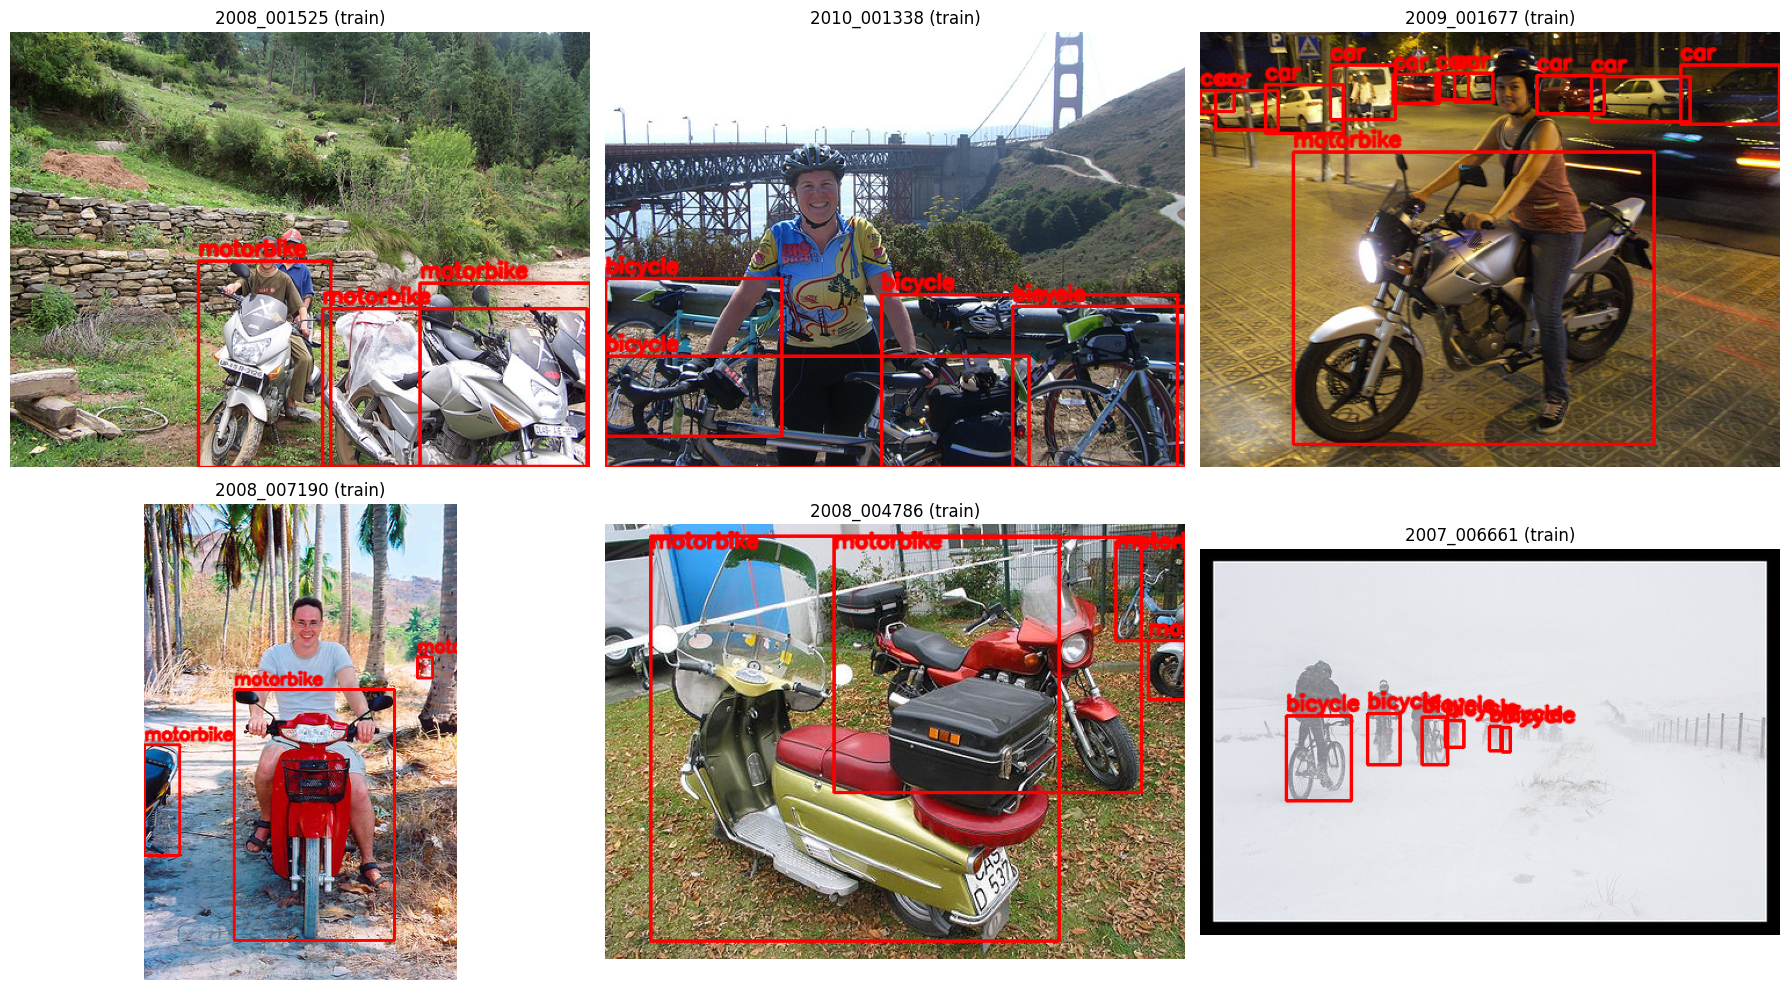

Saved preview grid to: F:\Projects\Object_Detection_Computer_Vision\reports\figures\annotation_preview_grid.png


In [19]:
# Cell 19

preview_rows = split_df.head(6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, preview_rows.iterrows()):
    image = draw_yolo_boxes(
        image_path=row["image_path"],
        label_path=row["label_path"],
        class_names=TARGET_CLASSES,
    )
    ax.imshow(image)
    ax.set_title(f"{row['image_id']} ({row['split']})")
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "annotation_preview_grid.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved preview grid to: {FIGURES_DIR / 'annotation_preview_grid.png'}")

In [20]:
# Cell 20

summary_rows = []

for split_name in ["train", "val", "test"]:
    split_part = split_df[split_df["split"] == split_name]

    row = {
        "split": split_name,
        "num_images": len(split_part),
        "car_objects": int(split_part["car_count"].sum()),
        "bus_objects": int(split_part["bus_count"].sum()),
        "bicycle_objects": int(split_part["bicycle_count"].sum()),
        "motorbike_objects": int(split_part["motorbike_count"].sum()),
    }
    summary_rows.append(row)

split_summary_df = pd.DataFrame(summary_rows)
display(split_summary_df)

save_csv(split_summary_df, CLASS_COUNTS_PATH)
print(f"Saved class counts to: {CLASS_COUNTS_PATH}")

,split,num_images,car_objects,bus_objects,bicycle_objects,motorbike_objects
0,train,105,183,106,143,117
1,val,22,39,24,12,43
2,test,23,52,30,26,16


Saved class counts to: F:\Projects\Object_Detection_Computer_Vision\reports\tables\class_counts.csv


In [21]:
# Cell 21

import yaml

data_yaml = {
    "path": str((PROJECT_ROOT / "data").resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "car",
        1: "bus",
        2: "bicycle",
        3: "motorbike",
    },
}

data_yaml_path = PROJECT_ROOT / "data" / "data.yaml"

with open(data_yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print(f"Saved data.yaml to: {data_yaml_path}")

Saved data.yaml to: F:\Projects\Object_Detection_Computer_Vision\data\data.yaml
